<>:216: SyntaxWarning: invalid escape sequence '\o'
<>:216: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_843/1774417229.py:216: SyntaxWarning: invalid escape sequence '\o'
  plt.xlabel('r / R$_\odot$')


Integrando n = 3.0...
Integrando n = 3.15...
Integrando n = 3.3...
Integrando n = 3.45...
Integrando n = 3.6...
Integrando n = 3.75...

=== TABLA DE PARÁMETROS ===
         n       xi1                dtheta1  rho_c/rho_m  -xi1^2 dtheta  omega_n      N_n      W_n  Pc (10^17 dyn/cm²)
0 3.000000  6.896849    -0.0424297576045481    54.182481       2.018236 2.018236 0.363939 0.081035            0.009134
1 3.150000  7.531873    -0.0348326343534082    72.076788       1.976025 1.716378 0.372199 0.074873            0.008439
2 3.300000  8.285036  -0.028222539399060286    97.853661       1.937247 1.470305 0.382779 0.069453            0.007828
3 3.450000  9.191474  -0.022509914915498995   136.110009       1.901710 1.265307 0.395984 0.064672            0.007289
4 3.600000 10.301590  -0.017614172888155536   194.948885       1.869265 1.091248 0.412277 0.060447            0.006813
5 3.750000 11.690294  -0.013462375217904542   289.455947       1.839808 0.940909 0.432342 0.056708            0.006392


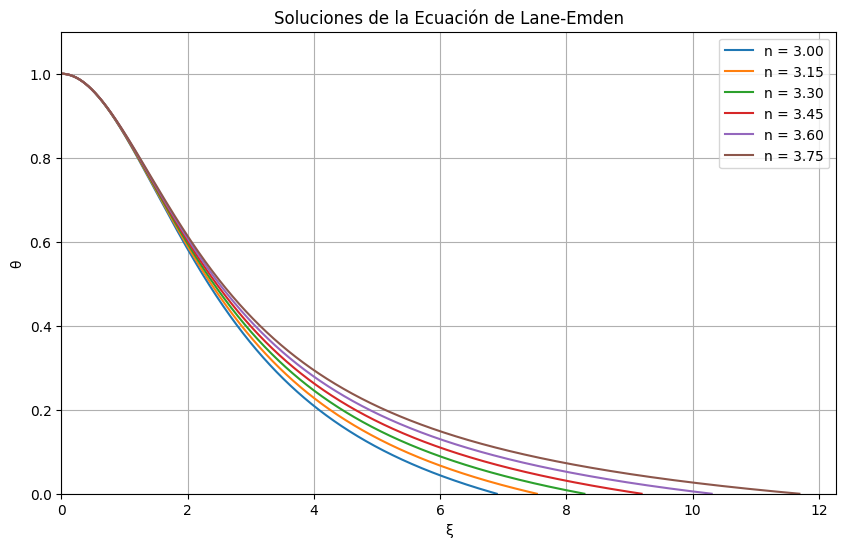

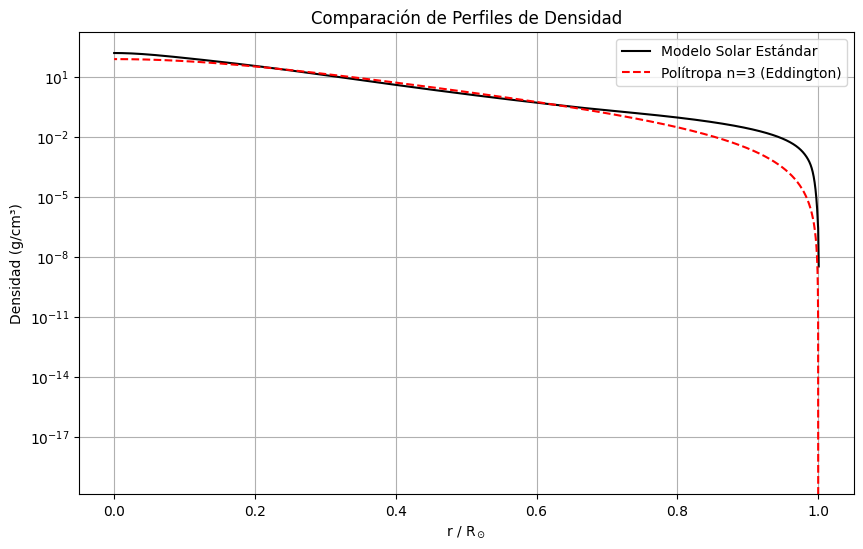

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline
from scipy.optimize import brentq
import pandas as pd

# Constantes físicas (CGS)
G = 6.674e-8          # cm**3 g**(-1) s**(-2)
M_sun = 1.989e33      # g
R_sun = 6.957e10      # cm


def lane_emden_system(xi, y1, y2, n):
    if xi == 0:
        return np.array([0.0, 0.0])
    dy1 = y2
    if y1 >= 0:
        source = y1**n
    else:
        source = 0.0
    dy2 = -source - (2.0/xi)*y2
    return np.array([dy1, dy2])

#Comentario lane_emden_system: 
#Convertimos la ecuación de Lane-Emden en un sistema de dos ecuaciones de primer grado equivalentes a la ecuación original 
#Una vez definido el sistema de dos ecuaciones agrego un "protecciones" para que no salgan problemas de las potencias (aquí seria bueno incluir la parte en que hago la explicación de las bases negativas elevadas número pequeños)
#Y a su vez establezco una medida de seguridad que es no comenzar en ξ = 0 si no en un pequeño valor de h así evito singularidades 

def rk4_step(xi, y1, y2, h, n):
    """Un paso de RK4 usando lane_emden_system"""
    k1 = h * lane_emden_system(xi, y1, y2, n)
    k2 = h * lane_emden_system(xi + h/2, y1 + k1[0]/2, y2 + k1[1]/2, n)
    k3 = h * lane_emden_system(xi + h/2, y1 + k2[0]/2, y2 + k2[1]/2, n)
    k4 = h * lane_emden_system(xi + h, y1 + k3[0], y2 + k3[1], n)
    
    y1_new = y1 + (k1[0] + 2*k2[0] + 2*k3[0] + k4[0])/6.0
    y2_new = y2 + (k1[1] + 2*k2[1] + 2*k3[1] + k4[1])/6.0
    return y1_new, y2_new

#Comentario de rk4_step: 
#Como se puede ver en la definición lo primero que hacemos es hallar las 4 pendientes K_n con pasos de tamaño h 
#evaluando los puntos intermedios del intervalo para posteriormente colocarle sus pesos respectivos

def taylor_start(h, n):
    """Valores iniciales en xi = h usando expansión de Taylor"""
    theta = 1.0 - h**2/6.0 + n*h**4/120.0
    dtheta = -h/3.0 + n*h**3/30.0
    return theta, dtheta

#Comentario taylor_start: 
#Hacemos la expansión de Taylor alrededor de ξ = 0 y evaluamos estas expresiones en ξ = h para hallar los valores iniciales

def find_surface(xi_array, theta_array, dtheta_array):
    # Encontrar índice del primer cambio de signo (de + a -)
    signs = np.sign(theta_array)
    sign_changes = np.where(np.diff(signs) < 0)[0]  # solo cambios de + a -
    if len(sign_changes) == 0:
        # No se encontró cruce: quizá no se llegó a negativo, usar último punto
        print("Advertencia: No se detectó cambio de signo. Usando último punto.")
        xi1 = xi_array[-1]
        cs_dtheta = CubicSpline(xi_array[-4:], dtheta_array[-4:])
        dtheta1 = cs_dtheta(xi1)
        return xi1, dtheta1
    
    idx = sign_changes[0]
    # Asegurar que los puntos alrededor no tengan NaN
    i1 = max(0, idx-2)
    i2 = min(len(xi_array), idx+3)
    xi_seg = xi_array[i1:i2]
    theta_seg = theta_array[i1:i2]
    dtheta_seg = dtheta_array[i1:i2]
    
    # Comprobar que no hay NaN en el segmento
    if np.any(np.isnan(theta_seg)) or np.any(np.isnan(dtheta_seg)):
        raise ValueError("Segmento contiene NaN; revisa la integración.")
    
    cs_theta = CubicSpline(xi_seg, theta_seg)
    xi_left = xi_array[idx]
    xi_right = xi_array[idx+1]
    try:
        xi1 = brentq(cs_theta, xi_left, xi_right)
    except ValueError:
        # Fallback a interpolación lineal
        theta_left = theta_array[idx]
        theta_right = theta_array[idx+1]
        xi1 = xi_left - theta_left * (xi_right - xi_left)/(theta_right - theta_left)
    
    cs_dtheta = CubicSpline(xi_seg, dtheta_seg)
    dtheta1 = cs_dtheta(xi1)
    return xi1, dtheta1

#Comentarios find_surface:
#Explicar esto

def integrate_lane_emden(n, h=1e-4, max_steps=500000): #500000 #1000000 #5000000
    xi = h
    y1, y2 = taylor_start(h, n)
    
    xi_list = [xi]
    theta_list = [y1]
    dtheta_list = [y2]
    
    for step in range(max_steps):

    # CORTE ANTES del RK4
        #if y1 < 1e-6:
        #    break

        # luego RK4
        y1_new, y2_new = rk4_step(xi, y1, y2, h, n)
        xi_new = xi + h

        xi_list.append(xi_new)
        theta_list.append(y1_new)
        dtheta_list.append(y2_new)

        if y1_new < 0:
            break

        y1, y2, xi = y1_new, y2_new, xi_new
    
    xi_arr = np.array(xi_list)
    theta_arr = np.array(theta_list)
    dtheta_arr = np.array(dtheta_list)
    
    # Verificar que no hay NaN antes de llamar a find_surface
    if np.any(np.isnan(dtheta_arr)) or np.any(np.isnan(theta_arr)):
        raise ValueError("Se detectaron NaN en la solución. Revisa el paso h o el manejo de la singularidad.")
    
    xi1, dtheta1 = find_surface(xi_arr, theta_arr, dtheta_arr)
    return xi_arr, theta_arr, dtheta_arr, xi1, dtheta1

#Comentarios integrate_lane_emden:
#Como su nombre lo dice integra la ecuación para un índice politrópico dado (n) hasta la superficie
#

def compute_parameters(n, xi1, dtheta1):
    """Calcula los parámetros físicos solicitados"""
    rho_m = M_sun / (4/3 * np.pi * R_sun**3)
    rho_c = - (xi1/3) / dtheta1 * rho_m
    conc_ratio = rho_c / rho_m
    
    mass_param = -xi1**2 * dtheta1
    
    # Para n != 1, evitamos complejos con valor absoluto
    if n != 1:
        omega = abs(-xi1**((n+1)/(n-1)) * dtheta1)
        Nn = (1/(n+1)) * (4*np.pi / omega**(n-1))**(1/n)
    else:
        omega = 0.0
        Nn = 0.0
    
    Wn = 1/(4*np.pi*(n+1)) * mass_param**2
    Pc = Wn * (G * M_sun**2 / R_sun**4)
    
    return {
        'n': n,
        'xi1': xi1,
        'dtheta1': dtheta1,
        'rho_c/rho_m': conc_ratio,
        '-xi1^2 dtheta': mass_param,
        'omega_n': omega,
        'N_n': Nn,
        'W_n': Wn,
        'Pc (10^17 dyn/cm²)': Pc / 1e17
    }

#Comentarios compute_parameters:
#Explicar esto

# Ejecución para todos los n
n_values = [3.00, 3.15, 3.30, 3.45, 3.60, 3.75] #Quité 1, 1.5, 4.0, 4.5, 4.75, 5 para enfocarme en los valores que pide el documento también 3.50 que solo lo usé para comparación
results = []
all_profiles = {}

for n in n_values:
    print(f"Integrando n = {n}...")
    xi_arr, theta_arr, dtheta_arr, xi1, dtheta1 = integrate_lane_emden(n)
    all_profiles[n] = (xi_arr, theta_arr)
    params = compute_parameters(n, xi1, dtheta1)
    results.append(params)

# Tabla de resultados
df = pd.DataFrame(results)
print("\n=== TABLA DE PARÁMETROS ===")
print(df.to_string(float_format="{:.6f}".format))

# Gráfico 1: θ(ξ) para todos los n
plt.figure(figsize=(10,6))
for n in n_values:
    xi_arr, theta_arr = all_profiles[n]
    plt.plot(xi_arr, theta_arr, label=f'n = {n:.2f}')
plt.xlabel('ξ')
plt.ylabel('θ')
plt.title('Soluciones de la Ecuación de Lane-Emden')
plt.legend()
plt.grid(True)
plt.xlim(0, max([all_profiles[n][0][-1] for n in n_values])*1.05)
plt.ylim(0, 1.1)
plt.show()

# Comparación con modelo solar (solar_model.txt)
try:
    solar_data = np.loadtxt('solar_model.txt')
    # Asumimos columnas: r/R_sun, rho (g/cm³)
    r_solar = solar_data[:,0]
    rho_solar = solar_data[:,2]
    
    # Para n=3.0
    n_eddington = 3.0
    xi_arr, theta_arr = all_profiles[n_eddington]
    params_n3 = next(p for p in results if p['n']==3.0)
    xi1 = params_n3['xi1']
    r_ratio = xi_arr / xi1
    rho_c = params_n3['rho_c/rho_m'] * (M_sun / (4/3*np.pi*R_sun**3))
    rho_poly = rho_c * theta_arr**n_eddington
    
    # Interpolar en puntos del modelo solar
    from scipy.interpolate import interp1d
    interp_rho = interp1d(r_ratio, rho_poly, kind='cubic', fill_value='extrapolate')
    rho_poly_at_solar = interp_rho(r_solar)
    
    plt.figure(figsize=(10,6))
    plt.plot(r_solar, rho_solar, 'k-', label='Modelo Solar Estándar')
    plt.plot(r_solar, rho_poly_at_solar, 'r--', label='Polítropa n=3 (Eddington)')
    plt.xlabel('r / R$_\odot$')
    plt.ylabel('Densidad (g/cm³)')
    plt.title('Comparación de Perfiles de Densidad')
    plt.legend()
    plt.yscale('log')
    plt.grid(True)
    plt.show()
    
except FileNotFoundError:
    print("Archivo solar_model.txt no encontrado. Saltando comparación solar.")
except Exception as e:
    print(f"Error al procesar el modelo solar: {e}")

Integrando n = 1...
Integrando n = 1.5...
Integrando n = 3.0...
Integrando n = 3.15...
Integrando n = 3.3...
Integrando n = 3.45...
Integrando n = 3.5...
Integrando n = 3.6...
Integrando n = 3.75...
Integrando n = 4...
Integrando n = 4.5...
Integrando n = 4.75...
Advertencia: No se detectó cambio de signo. Usando último punto.
Integrando n = 5...
Advertencia: No se detectó cambio de signo. Usando último punto.

=== TABLA DE PARÁMETROS ===
          n       xi1                 dtheta1  rho_c/rho_m  -xi1^2 dtheta    omega_n      N_n      W_n  Pc (10^17 dyn/cm²)
0  1.000000  3.141593    -0.31830988621782114     3.289868       3.141593   0.000000 0.000000 0.392699            0.044262
1  1.500000  3.653754    -0.20330128263892375     5.990705       2.714055 132.384299 0.424217 0.234470            0.026427
2  3.000000  6.896849     -0.0424297576045481    54.182481       2.018236   2.018236 0.363939 0.081035            0.009134
3  3.150000  7.531873     -0.0348326343534082    72.076788       

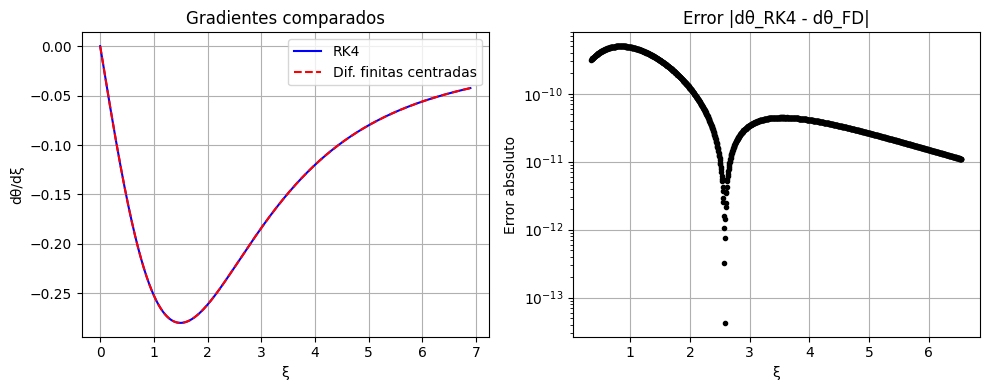

In [ ]:
#ESTO FUNCIONA BIEN CAMBIANDO LOS VALORES PERO NO DEVUELVE LA TABLA PORQUE NO PUSE ESA PARTE DEL CÓDIGO, DEBERÍA PONERLA PORQUE AL DEVOLVER LA TABLA VEMOS EL COMPORTAMIENTO DE HECHO PIENSO QUE DEBERÍA DEJAR UNA COPIA TAL 
#CUAL DEL CÓDIGO Y OTRA QUE SEA SOLO VERIFICACIÓN Y QUE SE PUEDA OMITIR, PRIMERO EL CÓDIGO LIMPIO Y LUEGO EL MISMO CÓDIGO CON TODA LA SECCIÓN DE VERIFICACIÓN 

# Ejecución para todos los n

n_values = [1,1.5,3.00, 3.15, 3.30, 3.45,3.50,3.60, 3.75,4,4.5,4.75,5]
results = []
all_profiles = {}

for n in n_values:
    print(f"Integrando n = {n}...")
    xi_arr, theta_arr, dtheta_arr, xi1, dtheta1 = integrate_lane_emden(n)
    all_profiles[n] = (xi_arr, theta_arr)
    params = compute_parameters(n, xi1, dtheta1)
    results.append(params)

# Tabla de resultados
df = pd.DataFrame(results)
print("\n=== TABLA DE PARÁMETROS ===")
print(df.to_string(float_format="{:.6f}".format))



# ======================================================
# Verificación con valores de referencia
# ======================================================
ref_values = {
    # n: (xi1_ref, dtheta1_ref, mass_param_ref)
    0:   (2.4494897428, -0.40824829,  2.4494897),
    1:   (3.1415926536, -0.31830989,  3.1415927),
    1.5: (3.65375374,   -0.203300,    2.71406),
    3:   (6.8968486,    -0.0424298,   2.01824),
    3.5: (9.53581,      -0.018329,    1.6666),
    4:   (14.97155,     -0.004126,    0.9253),
    4.5: (31.8365,      -0.000343,    0.347),
    # n=5 no tiene xi1 finito
}

print("\n=== VERIFICACIÓN CON VALORES DE REFERENCIA ===")
print(f"{'n':<8} {'ξ₁ calc':<15} {'ξ₁ ref':<15} {'Error rel ξ₁':<15} "
      f"{'−ξ²θ’ calc':<15} {'−ξ²θ’ ref':<15} {'Error rel'}")

for n, (xi_ref, dtheta_ref, mass_ref) in ref_values.items():
    # Buscar en los resultados si este n fue integrado
    match = [p for p in results if abs(p['n'] - n) < 1e-12]
    if match:
        p = match[0]
        xi1_calc = p['xi1']
        dtheta1_calc = p['dtheta1']
        mass_calc = p['-xi1^2 dtheta']
        err_xi = abs(xi1_calc - xi_ref) / xi_ref * 100
        err_mass = abs(mass_calc - mass_ref) / mass_ref * 100
        print(f"{n:<8} {xi1_calc:<15.8f} {xi_ref:<15.8f} {err_xi:<15.6f} "
              f"{mass_calc:<15.8f} {mass_ref:<15.8f} {err_mass:<15.6f}")
    else:
        print(f"{n:<8} {'-- (no integrado) --'}")


#TODA ESTA VERIFICACIÓN ES PARA EL GRADIENTE 
def finite_difference_gradient(xi, theta, h):
    """
    Calcula la derivada de theta respecto a xi usando diferencias centradas (O(h^2)).
    Retorna array con NaN en los extremos.
    """
    dtheta_fd = np.full_like(theta, np.nan)
    n = len(xi)
    # Esquema centrado para puntos internos
    for i in range(1, n-1):
        dtheta_fd[i] = (theta[i+1] - theta[i-1]) / (2 * h)
    return dtheta_fd

# ----------------- Verificación de gradiente para n=3.0 -----------------
n_verify = 3.0
h = 1e-4  # debe coincidir con el paso usado
xi_arr, theta_arr, dtheta_arr, _, _ = integrate_lane_emden(n_verify, h=h)

# Calcular gradiente por diferencias finitas
dtheta_fd = finite_difference_gradient(xi_arr, theta_arr, h)

# Seleccionar puntos interiores para comparación (evitar bordes)
start_idx = max(10, int(0.05 * len(xi_arr)))  # saltar primeros 5%
end_idx = len(xi_arr) - start_idx
sample_indices = np.arange(start_idx, end_idx, 50)  # cada 50 puntos

xi_sam = xi_arr[sample_indices]
dtheta_rk4 = dtheta_arr[sample_indices]
dtheta_fd_sam = dtheta_fd[sample_indices]

# Calcular errores
abs_error = np.abs(dtheta_rk4 - dtheta_fd_sam)
rel_error = abs_error / np.abs(dtheta_rk4)  # puede ser grande si gradiente ~0, pero en la zona de interés no

# Mostrar estadísticas
print(f"\n--- Verificación del gradiente para n = {n_verify} ---")
print(f"Índices de muestra: {len(sample_indices)} puntos entre xi = {xi_sam[0]:.4f} y {xi_sam[-1]:.4f}")
print(f"Error absoluto máximo: {np.max(abs_error):.2e}")
print(f"Error relativo máximo: {np.max(rel_error[~np.isnan(rel_error)]):.2%}")
print(f"Error absoluto medio: {np.mean(abs_error):.2e}")

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(xi_arr, dtheta_arr, 'b-', label='RK4')
plt.plot(xi_arr, dtheta_fd, 'r--', label='Dif. finitas centradas')
plt.xlabel('ξ'); plt.ylabel('dθ/dξ')
plt.legend(); plt.grid(True)
plt.title('Gradientes comparados')

plt.subplot(1,2,2)
plt.semilogy(xi_sam, abs_error, 'k.')
plt.xlabel('ξ'); plt.ylabel('Error absoluto')
plt.grid(True)
plt.title('Error |dθ_RK4 - dθ_FD|')
plt.tight_layout()
plt.show()